In [21]:
import pandas as pd
import numpy as np
import arff
from glob import glob

# Sklearn / Imputation / Scaling / Model
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

In [22]:
# Load Dataset

from scipy.io import arff
import pandas as pd

def load_arff_file(path):
    """Load a single ARFF file and clean the data."""
    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)

    # Convert byte columns to numeric if needed
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)
            try:
                df[col] = df[col].astype(float)
            except ValueError:
                pass

    # Ensure class column is integer (0/1)
    if 'class' in df.columns:
        df['class'] = df['class'].astype(int)
    else:
        raise ValueError(f"'class' column not found in {path}")
    return df

file_names = ["1year.arff", "2year.arff", "3year.arff", "4year.arff", "5year.arff"]
year_datasets = {}

for i, fname in enumerate(file_names, start=1):
    df = load_arff_file(fname)
    df['company_name'] = [f"Company_{j}" for j in range(1, len(df)+1)]
    year_datasets[i] = df

print("✅ Loaded datasets for horizons:", list(year_datasets.keys()))

✅ Loaded datasets for horizons: [1, 2, 3, 4, 5]


In [23]:
# ===========================================
# TRAIN + VALIDATE + TEST PIPELINE (FINAL)
# ===========================================

models = {}
evals = {}

THRESHOLD = 0.35   # custom classification decision threshold

for horizon, df in year_datasets.items():
    
    print(f"\n{'='*50}")
    print(f"🏁 TRAINING & EVALUATION: {horizon}-Year Horizon")
    print(f"{'='*50}")

    # -------------------------------
    # STEP 1: Prepare data
    # -------------------------------
    X = df.drop(columns=['class', 'company_name'])
    y = df['class'].astype(int)

    # 70-15-15 split
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y,
        test_size=0.15,
        random_state=42,
        stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=0.1765,  # gives 15% of whole
        random_state=42,
        stratify=y_train_val
    )

    print(f"📊 Data Split Summary → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    # -------------------------------
    # STEP 2: Handle class imbalance
    # -------------------------------
    pos_count = int(y_train.sum())
    neg_count = int(len(y_train) - pos_count)
    pos_weight = (neg_count / pos_count) if pos_count > 0 else 1.0

    # -------------------------------
    # STEP 3: Build model pipeline
    # -------------------------------
    pipe = Pipeline([
        ("imputer", IterativeImputer(random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            scale_pos_weight=pos_weight,
            objective="binary",
            random_state=42
        ))
    ])

    # -------------------------------
    # STEP 4: Train full model
    # -------------------------------
    pipe.fit(X_train, y_train)
    models[horizon] = pipe

    # -------------------------------
    # STEP 5: Validation (threshold = 0.5)
    # -------------------------------
    val_pred = pipe.predict(X_val)
    val_proba = pipe.predict_proba(X_val)[:, 1]

    val_acc = accuracy_score(y_val, val_pred)
    val_prec = precision_score(y_val, val_pred, zero_division=0)
    val_rec = recall_score(y_val, val_pred, zero_division=0)
    val_f1 = f1_score(y_val, val_pred, zero_division=0)
    val_auc = roc_auc_score(y_val, val_proba)

    print(f"\n📈 Validation Metrics (15% data):")
    print(f"Accuracy : {val_acc:.3f}")
    print(f"Precision: {val_prec:.3f}")
    print(f"Recall   : {val_rec:.3f}")
    print(f"F1-Score : {val_f1:.3f}")
    print(f"AUC-ROC  : {val_auc:.3f}")

    # -------------------------------
    # STEP 6: Final TEST using THRESHOLD = 0.35
    # -------------------------------
    probs = pipe.predict_proba(X_test)[:, 1]
    y_pred = (probs > THRESHOLD).astype(int)

    # Safe metric wrapper
    def safe_metric(fn, *args, **kwargs):
        try:
            return fn(*args, **kwargs)
        except:
            return np.nan

    acc = safe_metric(accuracy_score, y_test, y_pred)
    prec = safe_metric(precision_score, y_test, y_pred, zero_division=0)
    rec = safe_metric(recall_score, y_test, y_pred, zero_division=0)
    f1 = safe_metric(f1_score, y_test, y_pred, zero_division=0)
    auc = safe_metric(roc_auc_score, y_test, probs)
    cm  = confusion_matrix(y_test, y_pred)

    print(f"\n Final TEST Metrics (THRESHOLD = {THRESHOLD})")
    print("-" * 34)
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-Score : {f1:.3f}")
    print(f"AUC-ROC  : {auc:.3f}")
    print("Confusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))

    # -------------------------------
    # STEP 7: Save metrics
    # -------------------------------
    evals[horizon] = {
        "val_acc": val_acc,
        "val_f1": val_f1,
        "val_auc": val_auc,
        "test_acc": acc,
        "test_prec": prec,
        "test_rec": rec,
        "test_f1": f1,
        "test_auc": auc,
        "test_cm": cm
    }

print("\n🏁 All models trained, validated, and evaluated with THRESHOLD = 0.35!")

# -------------------------------------------
# SUMMARY TABLE
# -------------------------------------------
summary = pd.DataFrame.from_dict(evals, orient="index")[[
    "val_acc", "val_f1", "val_auc",
    "test_acc", "test_f1", "test_auc"
]]

print("\n================= PERFORMANCE SUMMARY =================")
print(summary.round(3).to_string())
print("========================================================")



🏁 TRAINING & EVALUATION: 1-Year Horizon
📊 Data Split Summary → Train: 4917, Val: 1055, Test: 1055

📈 Validation Metrics (15% data):
Accuracy : 0.984
Precision: 0.929
Recall   : 0.634
F1-Score : 0.754
AUC-ROC  : 0.913

 Final TEST Metrics (THRESHOLD = 0.35)
----------------------------------
Accuracy : 0.975
Precision: 0.714
Recall   : 0.610
F1-Score : 0.658
AUC-ROC  : 0.930
Confusion Matrix:
[[1004   10]
 [  16   25]]

Classification Report:
              precision    recall  f1-score   support

           0      0.984     0.990     0.987      1014
           1      0.714     0.610     0.658        41

    accuracy                          0.975      1055
   macro avg      0.849     0.800     0.823      1055
weighted avg      0.974     0.975     0.974      1055


🏁 TRAINING & EVALUATION: 2-Year Horizon
📊 Data Split Summary → Train: 7120, Val: 1527, Test: 1526

📈 Validation Metrics (15% data):
Accuracy : 0.982
Precision: 0.971
Recall   : 0.567
F1-Score : 0.716
AUC-ROC  : 0.950

 Final 

In [24]:
#Gives the top 15 attributes for each horizon
import shap
import numpy as np
import pandas as pd

feature_contributions = {}

for horizon, pipe in models.items():
    print(f"\n========= HORIZON {horizon} YEAR =========")

    # full dataset
    df = year_datasets[horizon]
    Xh = df.drop(columns=['class', 'company_name'])
    
    # model
    model = pipe.named_steps["clf"]

    # --- LightGBM Importance ---
    lgbm_importance = pd.Series(
        model.feature_importances_,
        index=Xh.columns,
        name='lgbm_importance'
    )

    # --- SHAP Importance ---
    X_transformed = pipe.named_steps["scaler"].transform(
        pipe.named_steps["imputer"].transform(Xh)
    )
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_transformed)
    shap_importance = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=Xh.columns,
        name='shap_mean_abs'
    )

    # --- Combined Score ---
    combined = (
        lgbm_importance.rank(ascending=False) +
        shap_importance.rank(ascending=False)
    )

    combined = combined.sort_values()
    
    feature_contributions[horizon] = pd.DataFrame({
        'LGBM Importance': lgbm_importance,
        'SHAP Mean |value|': shap_importance,
        'Combined Rank Score': combined
    }).sort_values('Combined Rank Score')

    print(feature_contributions[horizon].head(15))



========= HORIZON 1 YEAR =========
        LGBM Importance  SHAP Mean |value|  Combined Rank Score
Attr58             1430           1.738058                  3.0
Attr27             1252           1.967962                  3.0
Attr9              1028           0.713137                  9.0
Attr39              626           0.986771                  9.0
Attr5               872           0.881543                  9.0
Attr13              556           0.900320                 14.0
Attr30              595           0.589413                 15.0
Attr41              627           0.288254                 22.0
Attr56              565           0.389880                 22.0
Attr55              572           0.298546                 24.0
Attr45              446           0.334561                 26.0
Attr19              394           0.506219                 26.0
Attr47              404           0.475810                 27.0
Attr52              328           0.597492                 27.0
Attr

In [25]:
top15_per_horizon = {}

for h in feature_contributions:
    df_ranked = feature_contributions[h]
    top15 = df_ranked.head(15)
    top15_per_horizon[h] = list(top15.index)
    print(f"\nTop 10 Features for Horizon {h}:")
    print(top15.index.tolist())


Top 10 Features for Horizon 1:
['Attr58', 'Attr27', 'Attr9', 'Attr39', 'Attr5', 'Attr13', 'Attr30', 'Attr41', 'Attr56', 'Attr55', 'Attr45', 'Attr19', 'Attr47', 'Attr52', 'Attr49']

Top 10 Features for Horizon 2:
['Attr27', 'Attr58', 'Attr34', 'Attr46', 'Attr5', 'Attr24', 'Attr29', 'Attr36', 'Attr9', 'Attr21', 'Attr42', 'Attr39', 'Attr6', 'Attr55', 'Attr44']

Top 10 Features for Horizon 3:
['Attr5', 'Attr34', 'Attr27', 'Attr46', 'Attr58', 'Attr21', 'Attr39', 'Attr29', 'Attr41', 'Attr40', 'Attr37', 'Attr25', 'Attr56', 'Attr35', 'Attr24']

Top 10 Features for Horizon 4:
['Attr46', 'Attr27', 'Attr34', 'Attr5', 'Attr21', 'Attr58', 'Attr36', 'Attr24', 'Attr9', 'Attr13', 'Attr29', 'Attr56', 'Attr25', 'Attr40', 'Attr39']

Top 10 Features for Horizon 5:
['Attr27', 'Attr34', 'Attr21', 'Attr46', 'Attr35', 'Attr58', 'Attr36', 'Attr25', 'Attr24', 'Attr9', 'Attr39', 'Attr56', 'Attr29', 'Attr6', 'Attr41']


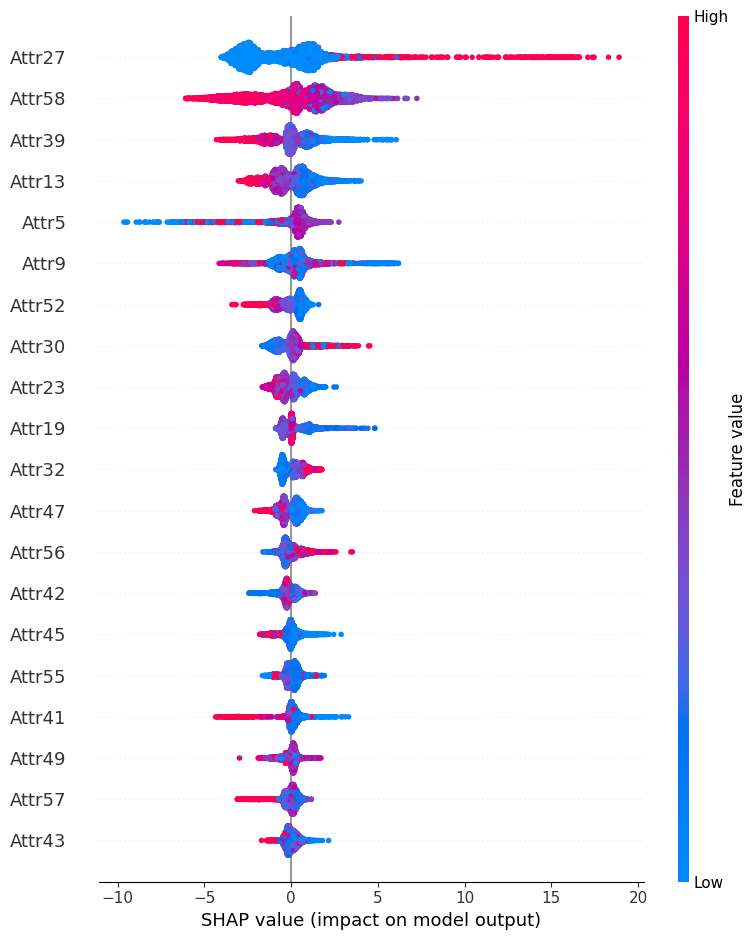

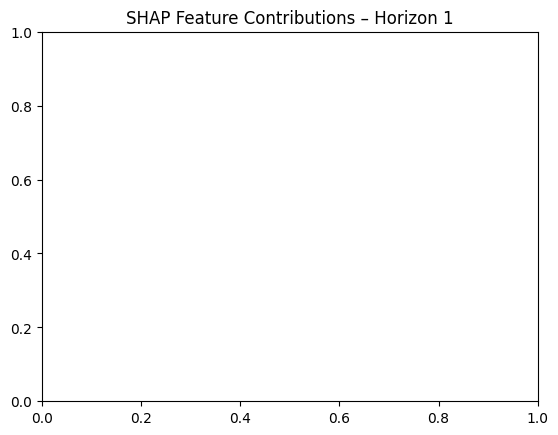

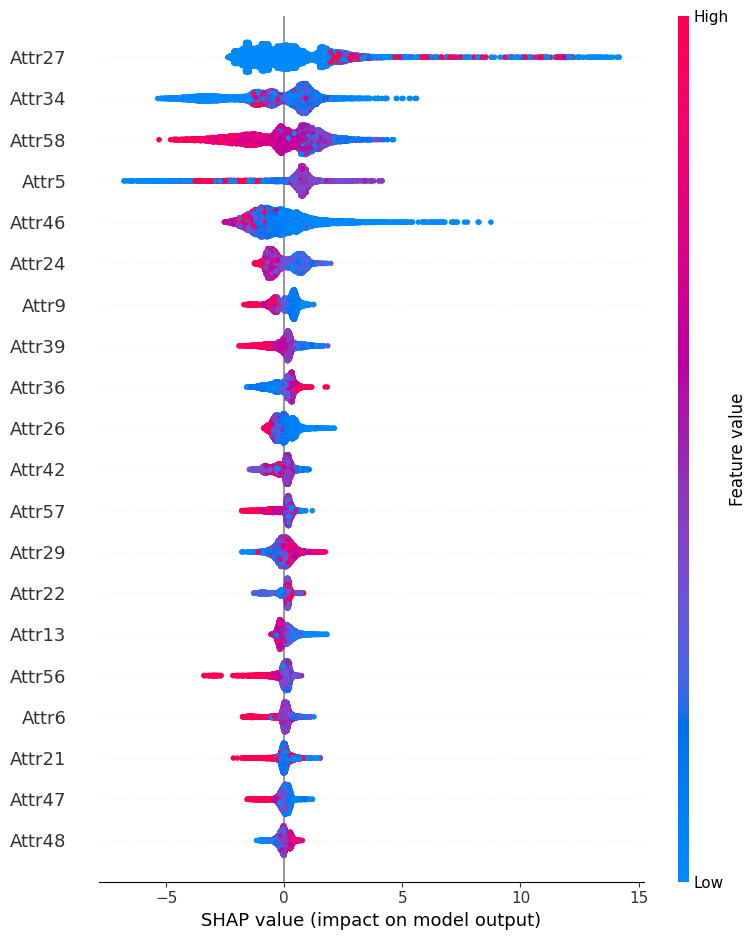

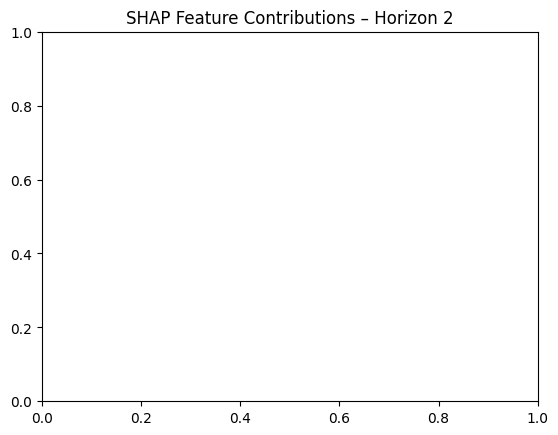

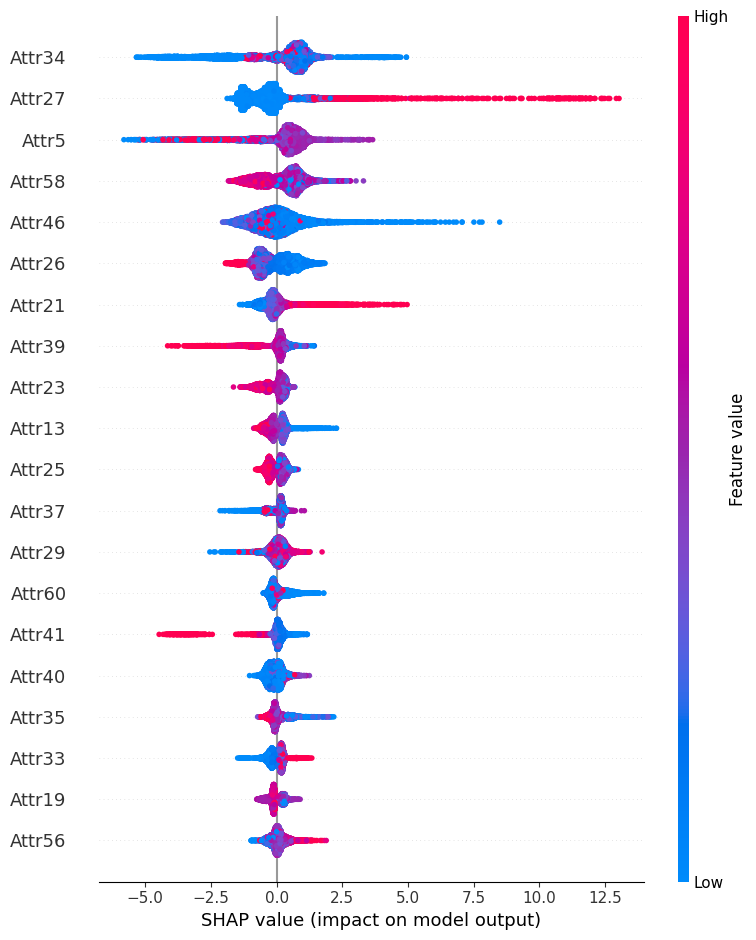

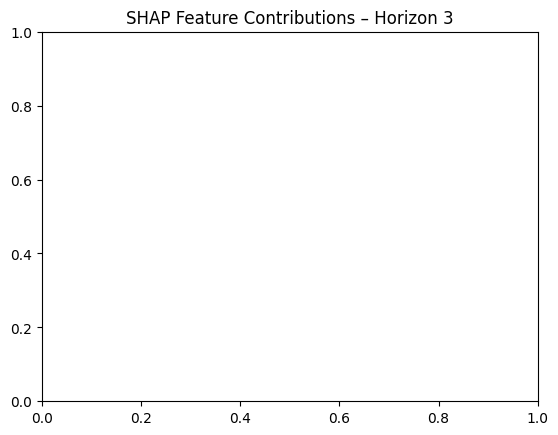

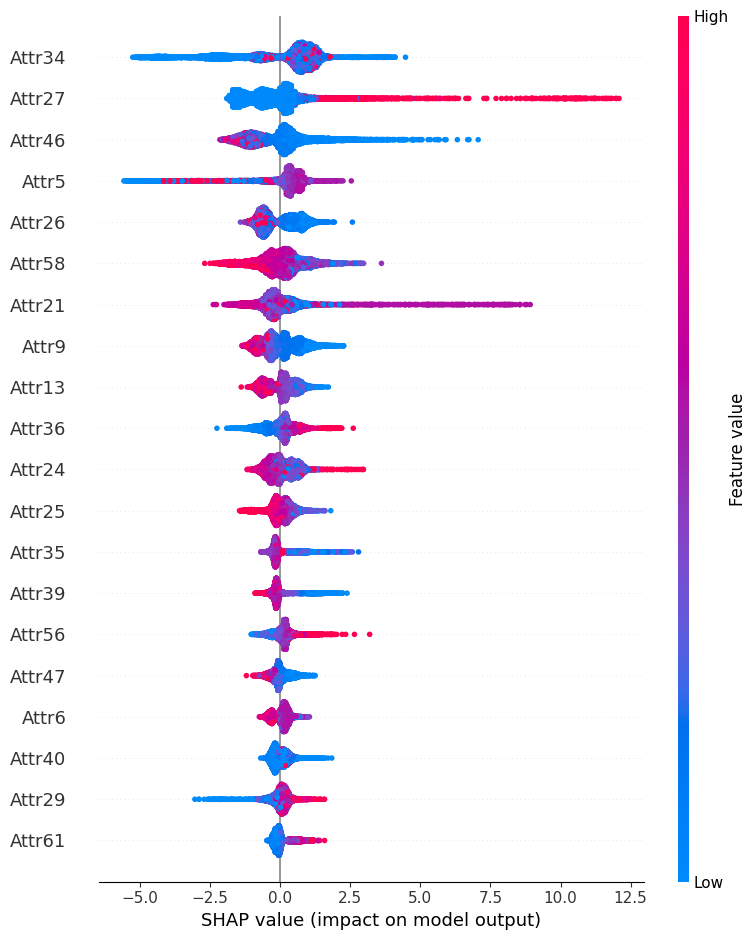

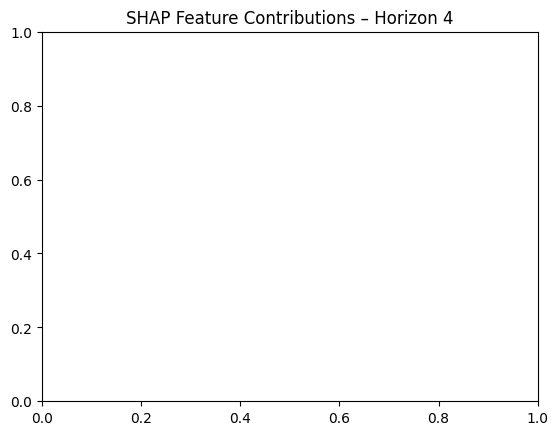

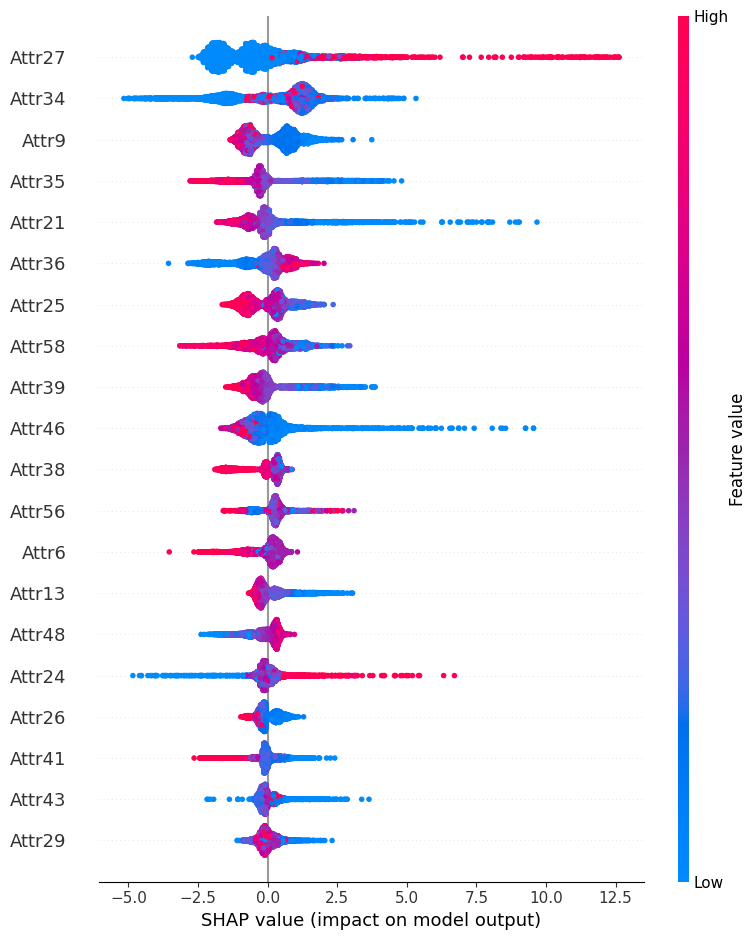

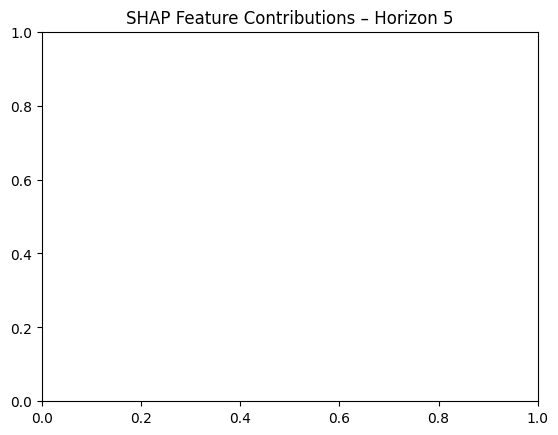

In [26]:
#Visualize contributions with SHAP summary plots
import matplotlib.pyplot as plt

for horizon, pipe in models.items():
    df = year_datasets[horizon]
    Xh = df.drop(columns=['class','company_name'])

    X_transformed = pipe.named_steps["scaler"].transform(
        pipe.named_steps["imputer"].transform(Xh)
    )
    model = pipe.named_steps["clf"]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_transformed)

    shap.summary_plot(
        shap_values,
        X_transformed,
        feature_names=Xh.columns,
        max_display=20
    )
    plt.title(f"SHAP Feature Contributions – Horizon {horizon}")
    plt.show()


In [27]:
# ======================================================
# TRAIN TOP-10 FEATURE MODELS + OPTIMAL F1 THRESHOLDS
# USING IMPROVED LIGHTGBM PARAMETERS
# ======================================================

import numpy as np
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from lightgbm import LGBMClassifier


# ------------------------------------------------------
# TOP 10 FEATURES PER HORIZON
# ------------------------------------------------------
top_features ={  
    1: ['Attr58', 'Attr27', 'Attr9', 'Attr39', 'Attr5', 'Attr13', 'Attr30', 'Attr41', 'Attr56', 'Attr55', 'Attr45', 'Attr19', 'Attr47', 'Attr52', 'Attr49'],
    2: ['Attr27', 'Attr58', 'Attr34', 'Attr46', 'Attr5', 'Attr24', 'Attr29', 'Attr36', 'Attr9', 'Attr21', 'Attr42', 'Attr39', 'Attr6', 'Attr55', 'Attr44'],
    3: ['Attr5', 'Attr34', 'Attr27', 'Attr46', 'Attr58', 'Attr21', 'Attr39', 'Attr29', 'Attr41', 'Attr40', 'Attr37', 'Attr25', 'Attr56', 'Attr35', 'Attr24'],
    4: ['Attr46', 'Attr27', 'Attr34', 'Attr5', 'Attr21', 'Attr58', 'Attr36', 'Attr24', 'Attr9', 'Attr13', 'Attr29', 'Attr56', 'Attr25', 'Attr40', 'Attr39'],
    5: ['Attr27', 'Attr34', 'Attr21', 'Attr46', 'Attr35', 'Attr58', 'Attr36', 'Attr25', 'Attr24', 'Attr9', 'Attr39', 'Attr56', 'Attr29', 'Attr6', 'Attr41']
}

models_top15 = {}
evals_top15 = {}
best_thresholds = {}


# ======================================================
# MAIN LOOP
# ======================================================
for horizon, df in year_datasets.items():

    print(f"\n========== TRAINING TOP-15 ATTR MODEL (HORIZON {horizon}) ==========")

    # -------------------------------
    # 1. Use only top 10 features
    # -------------------------------
    feats = top_features[horizon]
    X = df[feats]
    y = df["class"].astype(int)

    # 70-15-15 split
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.1765,
        random_state=42, stratify=y_train_val
    )

    # -------------------------------
    # 2. Class imbalance handling
    # -------------------------------
    pos = y_train.sum()
    neg = len(y_train) - pos
    pos_weight = (neg / pos) if pos > 0 else 1.0

    # -------------------------------
    # 3. IMPROVED LIGHTGBM MODEL
    # -------------------------------
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        #("scaler", StandardScaler()),
        ("clf", LGBMClassifier(
            n_estimators=2000,
            learning_rate=0.01,
            max_depth=-1,
            num_leaves=128,
            min_child_samples=10,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=pos_weight,
            objective="binary",
            random_state=42,
            n_jobs=-1,
            reg_lambda=0.7,
            reg_alpha=0.2,
            verbose = -1
        ))
    ])

    # 4. Train model
    pipe.fit(X_train, y_train)
    models_top15[horizon] = pipe

    # =====================================================
    # 5. OPTIMAL THRESHOLD (find best F1 on validation set)
    # =====================================================
    val_proba = pipe.predict_proba(X_val)[:, 1]

    best_thr = 0.5
    best_f1 = 0

    for thr in np.arange(0.05, 0.95, 0.01):
        pred_thr = (val_proba > thr).astype(int)
        f1_thr = f1_score(y_val, pred_thr, zero_division=0)
        if f1_thr > best_f1:
            best_f1 = f1_thr
            best_thr = thr

    best_thresholds[horizon] = best_thr
    print(f"Optimal Threshold = {best_thr:.2f}  |  Best Val F1 = {best_f1:.3f}")

    # -------------------------------
    # 6. FINAL VALIDATION METRICS
    # -------------------------------
    val_pred = (val_proba > best_thr).astype(int)

    val_acc = accuracy_score(y_val, val_pred)
    val_f1 = f1_score(y_val, val_pred, zero_division=0)
    val_auc = roc_auc_score(y_val, val_proba)

    # -------------------------------
    # 7. TEST METRICS USING BEST THRESHOLD
    # -------------------------------
    test_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = (test_proba > best_thr).astype(int)

    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    test_auc = roc_auc_score(y_test, test_proba)

    print(f"TEST → Acc: {test_acc:.3f}, F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

    # -------------------------------
    # 8. SAVE METRICS
    # -------------------------------
    evals_top15[horizon] = {
        "val_acc": val_acc,
        "val_f1": val_f1,
        "val_auc": val_auc,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "test_auc": test_auc,
        "best_thr": best_thr
    }

    # Save model
    joblib.dump(pipe, f"model_h{horizon}_top15_improved.pkl")
    print(f"Model saved → model_h{horizon}_top15_improved.pkl")


# ======================================================
# 9. SUMMARY TABLE
# ======================================================
summary_top15 = pd.DataFrame.from_dict(evals_top15, orient="index")
print("\n===== TOP-15 MODELS (Improved LightGBM + Optimized Thresholds) =====")
print(summary_top15.round(3).to_string())
print("=====================================================================")



========== TRAINING TOP-15 ATTR MODEL (HORIZON 1) ==========
Optimal Threshold = 0.60  |  Best Val F1 = 0.754
TEST → Acc: 0.980, F1: 0.704, AUC: 0.946
Model saved → model_h1_top15_improved.pkl

========== TRAINING TOP-15 ATTR MODEL (HORIZON 2) ==========
Optimal Threshold = 0.30  |  Best Val F1 = 0.723
TEST → Acc: 0.975, F1: 0.612, AUC: 0.913
Model saved → model_h2_top15_improved.pkl

========== TRAINING TOP-15 ATTR MODEL (HORIZON 3) ==========
Optimal Threshold = 0.19  |  Best Val F1 = 0.656
TEST → Acc: 0.960, F1: 0.519, AUC: 0.916
Model saved → model_h3_top15_improved.pkl

========== TRAINING TOP-15 ATTR MODEL (HORIZON 4) ==========
Optimal Threshold = 0.16  |  Best Val F1 = 0.647
TEST → Acc: 0.970, F1: 0.694, AUC: 0.914
Model saved → model_h4_top15_improved.pkl

========== TRAINING TOP-15 ATTR MODEL (HORIZON 5) ==========
Optimal Threshold = 0.41  |  Best Val F1 = 0.757
TEST → Acc: 0.967, F1: 0.739, AUC: 0.959
Model saved → model_h5_top15_improved.pkl

===== TOP-15 MODELS (Improved

In [13]:
import joblib

for h in models:
    joblib.dump(models[h], f"model_h{h}.pkl")

In [14]:
import json

with open("top15_per_horizon.json", "w") as f:
    json.dump(top15_per_horizon, f, indent=4)